# CZII - CryoET Object Identification

## Import

In [1]:
import zarr
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn import neighbors
import torch
from torch import nn
import torch.nn.functional as functional
import copy
from utilities import plot_3d_points
from matplotlib import cm
from matplotlib.colors import Normalize
import open3d as o3d
from torch.utils.data import Dataset, DataLoader
import json

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### Init dataset zarr files

In [76]:
low_res_dataset = {}
med_res_dataset = {}
hig_res_dataset = {}
for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/train/static/ExperimentRuns/'):
    for subdir in subdirnames:
        if 'zarr' in subdir:
            experiment_run = dirname.split("/")[-2]
            z = zarr.open(os.path.join(dirname, subdir), mode='r')
            hig_res_dataset[experiment_run] = z[0]
            med_res_dataset[experiment_run] = z[1]
            low_res_dataset[experiment_run] = z[2]

In [121]:
particles_locations = {}
for dirname, subdirnames, filenames in os.walk('../data/in/czii-cryo-et-object-identification/train/overlay/ExperimentRuns/'):
    for filename in filenames:
        if dirname.split("/")[-2] not in particles_locations:
            particles_locations[dirname.split("/")[-2]] = {}
        # particle_pos = {}
        with open(os.path.join(dirname, filename)) as f:
            d = json.load(f)
            name = d['pickable_object_name']
            points= []
            for point in d['points']:
                x, y, z = point['location']['x'], point['location']['y'], point['location']['z']
                points.append([x, y, z])
            particles_locations[dirname.split("/")[-2]][d['pickable_object_name']] = points
            # print(particle_pos)
            # particles_locations[dirname.split("/")[-2]] = particle_pos

for experiment in particles_locations:
    print(experiment)
    for particle in particles_locations[experiment]:
        print("\t" + particle, len(particles_locations[experiment][particle]))


TS_86_3
	beta-galactosidase 23
	thyroglobulin 45
	apo-ferritin 64
	ribosome 55
	beta-amylase 9
	virus-like-particle 29
TS_5_4
	beta-galactosidase 12
	thyroglobulin 30
	apo-ferritin 46
	ribosome 31
	beta-amylase 10
	virus-like-particle 11
TS_73_6
	beta-galactosidase 14
	thyroglobulin 28
	apo-ferritin 95
	ribosome 46
	beta-amylase 12
	virus-like-particle 22
TS_99_9
	beta-galactosidase 24
	thyroglobulin 49
	apo-ferritin 36
	ribosome 65
	beta-amylase 21
	virus-like-particle 13
TS_69_2
	beta-galactosidase 16
	thyroglobulin 34
	apo-ferritin 35
	ribosome 37
	beta-amylase 12
	virus-like-particle 9
TS_6_6
	beta-galactosidase 11
	thyroglobulin 35
	apo-ferritin 41
	ribosome 23
	beta-amylase 14
	virus-like-particle 19
TS_6_4
	beta-galactosidase 12
	thyroglobulin 30
	apo-ferritin 58
	ribosome 74
	beta-amylase 9
	virus-like-particle 10


#### Plotting images of tomogram

(184, 630, 630)


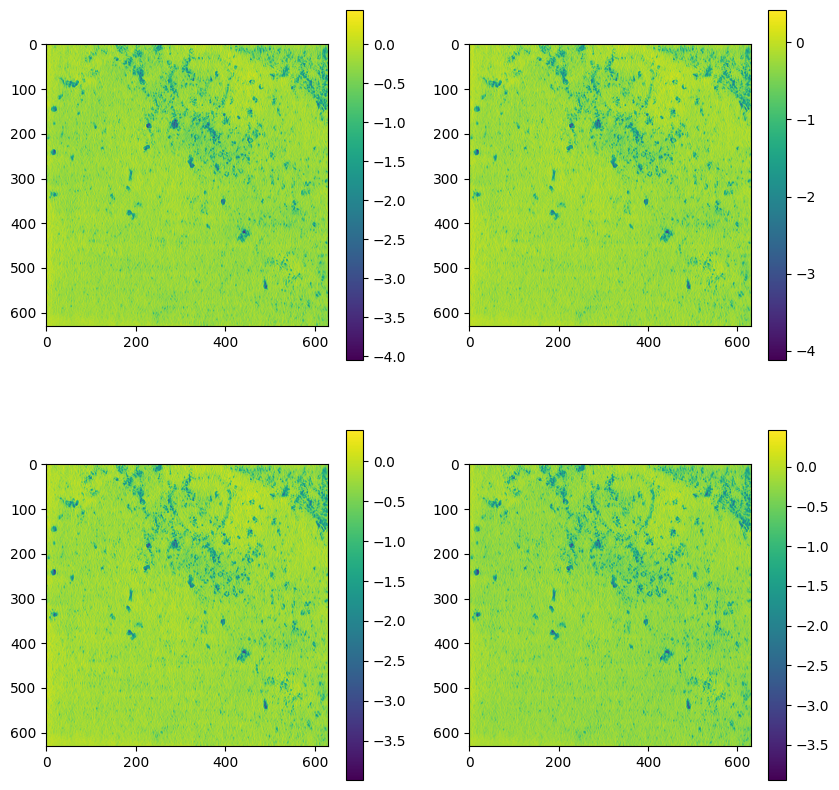

In [ ]:
for experiment_run in low_res_dataset:
    z1 = hig_res_dataset[experiment_run]
fig = plt.figure(figsize=(10,10))

start = 23
i = 0
for i in range(z1.shape[0]):
    if i < start:
        continue
    if i > start+3:
        break
    ax = plt.subplot(2, 2, i-start+1)
    _ = plt.imshow(z1[i, :, :])
    plt.colorbar()

#### Plotting 3d representation

In [72]:
scans = np.array(low_res_dataset['TS_5_4'])
norm = Normalize(vmin=scans.min(), vmax=scans.max())

point_cloud = o3d.geometry.PointCloud()
points = []
colors = []
c_values = [np.array(cm.viridis(scans[0][0][0])[:3])]
for experiment_run in range(scans.shape[0]):
    for x in range(scans.shape[1]):
        for y in range(scans.shape[2]):
            points.append(np.array((experiment_run, x, y)))
            color = np.array(cm.viridis(norm(scans[experiment_run][x][y]))[:3])
            # for value in c_values:
                # if np.linalg.norm(value - color) != 0:
                #     c_values.append(color)
                #     print(color)
            colors.append(color)
point_cloud.points = o3d.utility.Vector3dVector(points)
point_cloud.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([point_cloud])

#### Plotting RGB channel for points

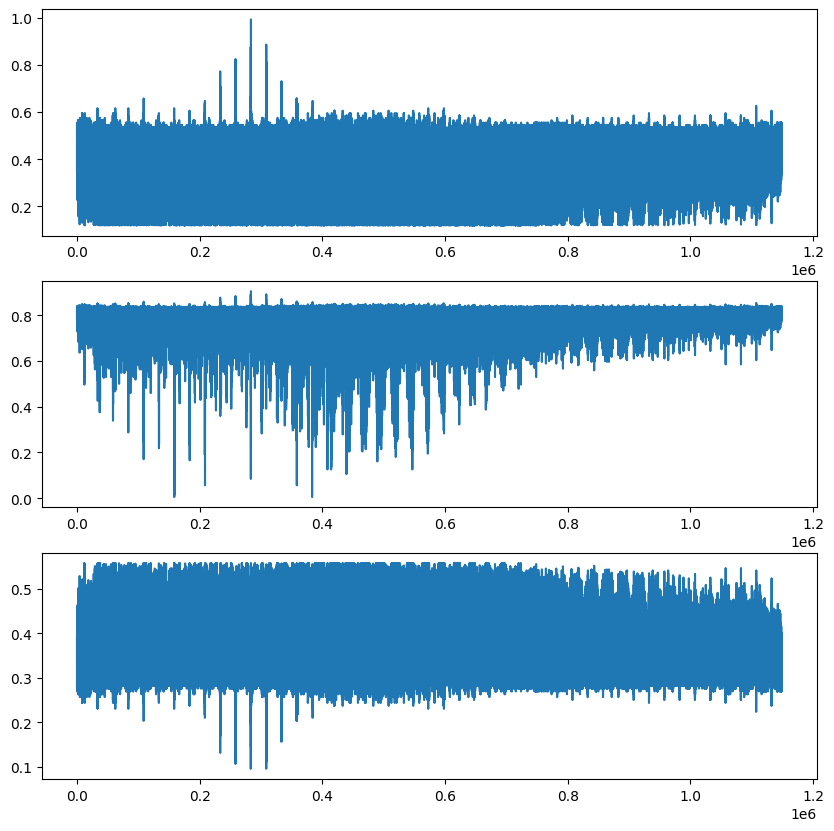

In [73]:
fig = plt.figure(figsize=(10,10))

ax = plt.subplot(3, 1, 1)
ax.plot(np.arange(len(colors)), np.array(colors)[:, 0])
ax = plt.subplot(3, 1, 2)
ax.plot(np.arange(len(colors)), np.array(colors)[:, 1])
ax = plt.subplot(3, 1, 3)
ax.plot(np.arange(len(colors)), np.array(colors)[:, 2])

### Creating dataset

In [ ]:
class CZII_Dataset(Dataset):
    def __init__(self, tomograms, locations):
        self.ys = locations
        self.xs = list(tomograms)

    def __len__(self):
        return len(self.xs)
    
    def __getitem__(self, idx):
        y = self.ys.iloc[idx]
        x = torch.Tensor(np.array(self.xs.iloc[idx]))
        return x, y
